# M0 — Environment & API Extension for the Inelastic RT Forward Model

First milestone of the **inelastic** coding plan
([`design/rt_inelastic_model_coding_plan.md`](../../design/rt_inelastic_model_coding_plan.md)),
which adds Raman scattering and chlorophyll-a fluorescence to the elastic hybrid as

$$R_{rs}^{\rm total} = \left(R_{rs}^{\rm ZTT} + \Delta R_{rs}\right)\times f_R \; + \; R_{rs}^{\rm fl}$$

M0 builds nothing scientific. It delivers a green base with three properties: the JAX
stack runs in `ocean14` **on this machine** (tank server), the `robust/rt` API carries the
inelastic *types*, and the elastic behavior is provably untouched — `inelastic=None` is
**bit-identical** to the pre-extension hybrid, a guarantee this notebook spends a section on.

| M | Goal |
|---|------|
| **M0** | **Environment (this machine) & API extension — this notebook** |
| M1 | Ed module, excitation grid, X2/X4 data |
| M2 | Analytic Raman & fluorescence terms in JAX |
| M3 | Correction heads δ_R, δ_F |
| M4 | Validation — prototype done |

Companions: the design ([`rt_inelastic_model.md`](../../design/rt_inelastic_model.md)),
the implementation record
([`rt_inelastic_implementation.md`](../../design/rt_inelastic_implementation.md)), and the
elastic notebooks in this directory. **JAX itself is not re-explained here** — why
autodiff is the product, why float64 is a prerequisite for finite-difference gates, and
the dtype traps all live in
[`rt_elastic_coding_1.ipynb`](rt_elastic_coding_1.ipynb) (§3–§4) and still apply verbatim.

## 1. The environment

The elastic prototype was built on the laptop; this effort runs on the **tank server**,
where `ocean14` had **no JAX at all** until M0 (verified 2026-08-20, and the reason the
elastic install record could not simply be trusted here). The install followed the elastic
procedure — `pip install --dry-run` first, then only what is **purely additive**.

In [1]:
import importlib
import sys
from pathlib import Path

# This notebook lives in notebooks/RT/. `robust` is not pip-installed in
# `ocean14` (deliberately — the JAX stack is declared in requirements.txt
# only), so put the repo root on sys.path. Walking up to the directory
# containing robust/__init__.py keeps this working from anywhere.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'robust' / '__init__.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax

print(f'repo   : {REPO}')
print(f'Python {sys.version.split()[0]}\n')

for name in ['jax', 'jaxlib', 'flax', 'optax', 'jaxtyping',
             'numpy', 'scipy', 'xarray', 'pandas', 'emcee', 'pytest']:
    try:
        mod = importlib.import_module(name)
        print(f'  {name:<10} {getattr(mod, "__version__", "?")}')
    except ImportError:
        print(f'  {name:<10} not installed')

print(f'\ndefault backend : {jax.default_backend()}')
print(f'devices         : {jax.devices()}')


repo   : /mnt/tank/Oceanography/python/retrieve-or-bust
Python 3.14.6

  jax        0.11.1
  jaxlib     0.11.1
  flax       0.12.9
  optax      0.2.8
  jaxtyping  0.3.11
  numpy      2.4.6
  scipy      1.18.0


  xarray     2026.4.0
  pandas     3.0.3


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


  emcee      3.1.6
  pytest     9.1.1

default backend : cpu
devices         : [CpuDevice(id=0)]


Three notes from the install, all checked rather than assumed (implementation record §2.3):

- **The full `requirements.txt` would have been destructive here.** Its `git+` lines for
  `bing` and `ocpy` would have replaced this machine's *editable* checkouts — including the
  `bing` checkout on branch `inelastic-fixes`, the exact physics M2 must cross-check
  against. Only the JAX block (`jax flax optax jaxtyping`, 23 packages, zero
  uninstalls/upgrades) was installed. Confirmed by JXP (prompt 1, Q&A Q1).
- **This machine has an NVIDIA GPU.** The CPU wheel prints *"An NVIDIA GPU may be present
  … Falling back to cpu"* once per process — expected log noise, and exactly the CPU-only
  behavior the plan requires (CQ2); every device above must be a `CpuDevice`.
- **The elastic suite ran here for the first time**: 279 passed, matching the laptop count
  exactly. That run is the baseline the API extension below regresses against.

## 2. What M0 decided: the `Inelastic` pytree

The design (§3) fixes the fifth argument of `forward`:

```python
Inelastic(phi_C=0.02, raman=True, fluorescence=True,
          emission_shape='single', cdom_fl=None)
```

The M0 decision worth explaining is not the field list but **which fields are pytree
leaves and which are static metadata**:

- **`phi_C` is a leaf.** The fluorescence quantum yield is a *differentiable input* —
  retrieving it is the point (design DQ4), so `grad`/`vmap` must traverse it. Its
  derivative is physically meaningful by construction: the fluorescence term is
  `Rrs_fl = phi_C · K_fl`, linear in `phi_C`, so `∂/∂phi_C` *is* the kernel.
- **`raman`, `fluorescence`, `emission_shape` are static** (registered via
  `field(metadata=dict(static=True))`). They select code paths; tracing a boolean makes
  no sense, and `jit` should instead specialize — one compilation per process
  configuration, the same documented behavior as an optional field becoming non-`None`.
- **`cdom_fl` is a reserved hook** (design §8): a leaf slot for CDOM fluorescence, but
  `validate()` rejects any non-`None` value in v1 so the process cannot be silently
  "enabled" three milestones before it exists.

In [2]:
import dataclasses

import jax.numpy as jnp
import numpy as np

from robust.rt import types as T

inel = T.Inelastic()
print('defaults      :', inel)

leaves, treedef = jax.tree_util.tree_flatten(inel)
print('leaves        :', leaves, ' (phi_C only — the switches are static)')

_, treedef_off = jax.tree_util.tree_flatten(T.Inelastic(raman=False))
print('treedef changes with a switch:', treedef != treedef_off)

# vmap over per-scene quantum yields — the batched-retrieval shape.
batched = T.Inelastic(phi_C=jnp.asarray([0.01, 0.02, 0.04]))
print('vmap over phi_C:', jax.vmap(lambda i: 2.0 * i.phi_C)(batched))

# The derivative of a phi_C-linear stand-in IS the kernel, and it arrives
# *labelled* — grad of a scalar of an Inelastic returns an Inelastic.
K_toy = jnp.asarray([0.3, 1.7, 0.9])          # stand-in for K_fl(lambda)
g = jax.grad(lambda i: jnp.sum(i.phi_C * K_toy))(T.Inelastic(phi_C=jnp.asarray(0.02)))
print('grad type     :', type(g).__name__)
print('d/d(phi_C)    :', float(g.phi_C), ' == sum(K_toy) =', float(K_toy.sum()))


defaults      : Inelastic(phi_C=0.02, raman=True, fluorescence=True, emission_shape='single', cdom_fl=None)
leaves        : [0.02]  (phi_C only — the switches are static)
treedef changes with a switch: True


vmap over phi_C: [0.02 0.04 0.08]


grad type     : Inelastic
d/d(phi_C)    : 2.9000000953674316  == sum(K_toy) = 2.9000000953674316


## 3. Two optional fields, one precedent

`IOPs` gains `a_ph` (phytoplankton absorption — the fluorescence source term is
`b_F = phi_C · a_ph`) and `Geometry` gains an `Ed = (wave_Ed, Ed)` override (the seam
through which real-sky irradiances enter later; default is M1's packaged L23 spectra).
Both copy the `Geometry.wind` precedent exactly: **optional, default `None`, no leaves
when unset** — so every existing call site, `vmap` axis spec, and `tree_map` is untouched,
and the treedef changes only once a caller opts in (one `jit` recompile, already the
documented cost of optional fields).

`a_ph` is optional for a *physical* reason, not an API one: bulk-`a` callers get
elastic + Raman, but fluorescence needs the component split — there is no source term
without it (design §3). `validate()` also enforces `a_ph ≤ a` everywhere, since a
component exceeding its total is always a bookkeeping or unit error.

In [3]:
from robust.rt import conventions as C
from robust.rt import hybrid as H

N = C.N_WAVE

iops3 = T.IOPs(a=jnp.full(N, 0.15), bb_w=jnp.broadcast_to(C.bb_w(), (N,)),
               bb_p=jnp.full(N, 0.003))
iops4 = dataclasses.replace(iops3, a_ph=jnp.full(N, 0.05))
print('IOPs leaves      : without a_ph', len(jax.tree_util.tree_leaves(iops3)),
      '| with a_ph', len(jax.tree_util.tree_leaves(iops4)))

geom = T.Geometry.nadir(jnp.asarray(30.0))
geom_ed = dataclasses.replace(
    geom, Ed=(jnp.linspace(350.0, 750.0, 5), jnp.full(5, 1.0)))
print('Geometry leaves  : without Ed  ', len(jax.tree_util.tree_leaves(geom)),
      '| with Ed  ', len(jax.tree_util.tree_leaves(geom_ed)))

# 'The elastic path ignores it' — as arithmetic, not prose: bit-identical.
wave = jnp.asarray([440.0, 550.0])
tiny = T.IOPs(a=jnp.asarray([0.15, 0.12]), bb_w=C.bb_w(wave),
              bb_p=jnp.asarray([0.003, 0.003]))
tiny_ph = dataclasses.replace(tiny, a_ph=jnp.asarray([0.05, 0.03]))
pp = T.PhaseParams(B_p=jnp.asarray(0.0126))
a = H.rrs_forward(tiny, pp, geom, wave, 'ztt')
b = H.rrs_forward(tiny_ph, pp, geom_ed, wave, 'ztt')
print('elastic output with vs without a_ph & Ed: bit-identical =',
      bool(np.array_equal(np.asarray(a), np.asarray(b))))

# And the boundary validator catches the component-exceeds-total error.
try:
    dataclasses.replace(iops3, a_ph=jnp.full(N, 0.2)).validate()
except ValueError as err:
    print('validate() on a_ph > a:', err)


IOPs leaves      : without a_ph 3 | with a_ph 4


Geometry leaves  : without Ed   3 | with Ed   5


elastic output with vs without a_ph & Ed: bit-identical = True
validate() on a_ph > a: IOPs: a_ph exceeds total absorption a somewhere -- a_ph is a *component* of a, so this is a unit or bookkeeping error


## 4. Why bit-identical, and not merely close

The design (§1) demands that `forward(..., inelastic=None)` reproduce the elastic hybrid
**bit for bit**, and M0 pins that with a SHA-256 hash of the output on the committed
50-scene CI fixture. Why insist on exact equality when a tolerance of, say, 1e-6 would
"obviously" do?

Because *any* tolerance converts the guarantee into a judgment call, and the judgment is
unmakeable: ULP-level float noise is **exactly the signature of an accidentally
restructured elastic path**. The inelastic composition works partly below the surface, so
a natural M2 "simplification" would be to route *every* output — elastic included —
through the `rrs → Rrs` conversion once more, or to always multiply by the Raman factor,
relying on it being 1.0 with the process off. Some such refactors are exact in IEEE
arithmetic and some are not. A `rtol=1e-6` gate waves every one of them through; each is
invisible in any plot; and three refactors later the "elastic" output is an artifact of
restructuring history rather than the pinned model the whole inelastic effort claims to
leave untouched.

The escape is to make the question structural rather than numerical: the `None` branch
**returns down the pre-existing code route before any inelastic arithmetic exists**. The
no-op holds *by construction, not by cancellation* — so exact equality is free, and the
hash test costs one comparison. The pins were computed on the unmodified elastic code
immediately before `types.py`/`hybrid.py` were touched, and verified deterministic across
processes. (They are anchored to this machine's CPU/XLA — bit-identity across platforms is
not a JAX guarantee; JXP has acknowledged that caveat in prompt 1, Q&A Q2.)

Below: the pinned hashes re-verified live, then a measurement of just how "close but not
identical" an arithmetic no-op really is.

In [4]:
import hashlib

from robust.rt.data import l23
from robust.tests.test_inelastic_types import (
    PRE_CHANGE_SHA256_RRS_ABOVE,
    PRE_CHANGE_SHA256_RRS_BELOW,
)

# The committed 50-scene fixture — present in the repo, so no $OS_COLOR needed.
batch = l23.load_batch(reader=l23.npz_reader(
    REPO / 'robust' / 'tests' / 'files' / 'l23_small.npz'))

out = H.forward(batch.iops, batch.phase_params, batch.geometry, batch.wave,
                inelastic=None, check_domain=False)
rrs = H.rrs_forward(batch.iops, batch.phase_params, batch.geometry, batch.wave,
                    inelastic=None, check_domain=False)

sha = lambda arr: hashlib.sha256(np.asarray(arr).tobytes()).hexdigest()  # noqa: E731
print('Rrs  hash matches pre-change pin :', sha(out) == PRE_CHANGE_SHA256_RRS_ABOVE)
print('rrs  hash matches pre-change pin :', sha(rrs) == PRE_CHANGE_SHA256_RRS_BELOW)

# --- how close is an arithmetic no-op? Route the elastic output once through
# --- the rrs <-> Rrs conversion pair. Algebraically the identity (the two maps
# --- are exact inverses of each other, and a test pins that); as a refactor,
# --- exactly the restructure M2 could plausibly make, since the inelastic
# --- composition works below the surface. In float32 it is not the identity.
x = np.asarray(out)                                   # (150, 81) float32
y = np.asarray(C.rrs_to_Rrs(C.Rrs_to_rrs(jnp.asarray(x))))

changed = y != x
rel = np.abs(y[changed] - x[changed]) / x[changed]
print(f'\narithmetic no-op rrs_to_Rrs(Rrs_to_rrs(x)) over {x.size} '
      'fixture elements:')
print(f'  elements with changed bits : {changed.sum()}  '
      f'({changed.mean():.1%})')
print(f'  median / max relative shift: {np.median(rel):.2e} / {rel.max():.2e}'
      f'   (float32 eps = {np.finfo(np.float32).eps:.2e})')
print(f'  code-route no-op (inelastic=None): 0 of {x.size} elements change')


Rrs  hash matches pre-change pin : True
rrs  hash matches pre-change pin : True

arithmetic no-op rrs_to_Rrs(Rrs_to_rrs(x)) over 12150 fixture elements:
  elements with changed bits : 4844  (39.9%)
  median / max relative shift: 8.18e-08 / 2.17e-07   (float32 eps = 1.19e-07)
  code-route no-op (inelastic=None): 0 of 12150 elements change


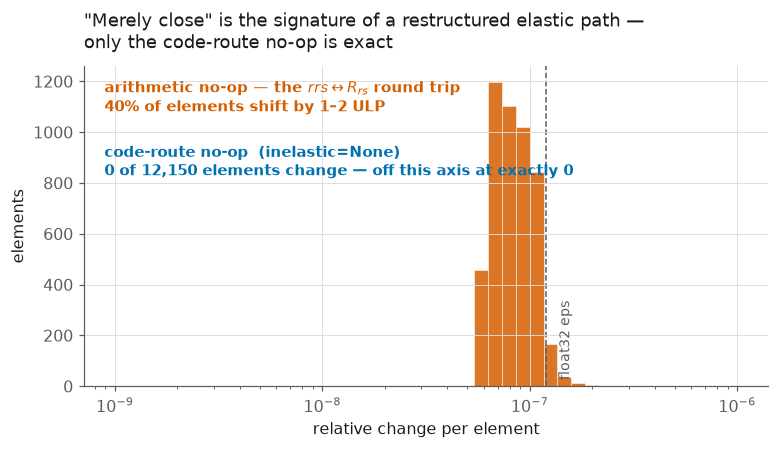

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- house style: recessive frame, ink-coloured text, one figure = one idea ---
INK, INK_MUTED, GRID = '#1a1a1a', '#5c5c5c', '#dcdcdc'
C_A, C_B = '#D55E00', '#0072B2'   # CVD-checked pair (elastic notebook 1)

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10.5,
    'axes.edgecolor': INK_MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(7.2, 4.2))

bins = np.logspace(-9, -6, 46)
ax.hist(rel, bins=bins, color=C_A, alpha=0.85, edgecolor='white', lw=0.4)

eps32 = np.finfo(np.float32).eps
ax.axvline(eps32, color=INK_MUTED, lw=1, ls='--', zorder=1)
ax.text(eps32 * 1.15, ax.get_ylim()[1] * 0.02, 'float32 eps',
        color=INK_MUTED, fontsize=9, rotation=90, va='bottom')

ax.annotate('arithmetic no-op — the $rrs \\leftrightarrow R_{rs}$ round trip\n'
            f'{changed.mean():.0%} of elements shift by 1–2 ULP',
            xy=(np.median(rel), 1), xytext=(0.03, 0.86),
            textcoords='axes fraction', color=C_A, fontweight='bold', fontsize=10)
ax.annotate(f'code-route no-op  (inelastic=None)\n0 of {x.size:,} elements change '
            '— off this axis at exactly 0',
            xy=(0.03, 0.66), xycoords='axes fraction', color=C_B,
            fontweight='bold', fontsize=10)

ax.set_xscale('log')
ax.set_xlabel('relative change per element')
ax.set_ylabel('elements')
ax.set_title('"Merely close" is the signature of a restructured elastic path —\n'
             'only the code-route no-op is exact',
             fontsize=11.5, pad=12, loc='left')
fig.tight_layout()
plt.show()


Read the histogram as a threat model. The conversion round trip is *algebraically the
identity* — the two maps are exact inverses, and a test in the elastic suite pins that —
yet it moves four in ten elements by one or two units in the last place. A tolerance gate
passes it silently; the hash test lights up. Conversely the pinned
hash costs nothing to keep green: the `None` branch simply never enters the inelastic
arithmetic, so there is nothing to drift. That asymmetry — expensive to violate
accidentally, free to satisfy honestly — is what makes the bit-identical gate the right
recurring guard from M0 through M4.

## 5. The baseline being frozen, and where M2 will touch it

For orientation: the elastic output this hash freezes, and the spectral regions the
inelastic physics will modify. Raman scattering redistributes blue photons into a broad
gain that matters most at 550–700 nm (the assessment's error table lives there);
chlorophyll fluorescence adds the narrow 685 nm emission peak. Everything below is the
committed fixture — 50 L23 scenes at three solar zeniths.

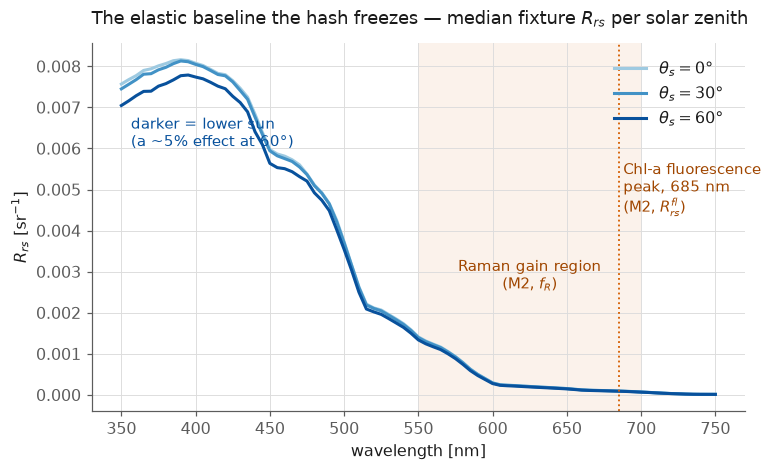

In [6]:
theta = np.asarray(batch.geometry.theta_s)
wave_np = np.asarray(batch.wave)

fig, ax = plt.subplots(figsize=(7.2, 4.4))

# Single hue light -> dark for the zenith sequence (elastic figure convention).
# The three medians sit within ~5% of each other, so per-curve labels would
# overprint; identity is carried by the legend plus the stated ordering.
BLUES = {0.0: '#9ecae1', 30.0: '#4292c6', 60.0: '#08519c'}
for tz, color in BLUES.items():
    med = np.median(np.asarray(out)[theta == tz], axis=0)
    ax.plot(wave_np, med, color=color, lw=2.0,
            label=f'$\\theta_s = {tz:.0f}°$')
ax.annotate('darker = lower sun\n(a ~5% effect at 60°)',
            xy=(0.06, 0.72), xycoords='axes fraction',
            color='#08519c', fontsize=9.5)
ax.legend(loc='upper right', bbox_to_anchor=(0.99, 0.99))

ax.axvspan(550, 700, color='#D55E00', alpha=0.08, lw=0)
ax.text(625, ax.get_ylim()[1] * 0.30, 'Raman gain region\n(M2, $f_R$)',
        color='#a04600', fontsize=9.5, ha='center')
ax.axvline(685, color='#D55E00', lw=1.2, ls=':')
ax.text(688, ax.get_ylim()[1] * 0.52, 'Chl-a fluorescence\npeak, 685 nm\n'
        '(M2, $R_{rs}^{fl}$)', color='#a04600', fontsize=9.5, ha='left')

ax.set_xlabel('wavelength [nm]')
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_title('The elastic baseline the hash freezes — median fixture $R_{rs}$ '
             'per solar zenith', fontsize=11.5, pad=12, loc='left')
fig.tight_layout()
plt.show()


Two forward-looking notes. The official wavelength support of the inelastic model is
**400–750 nm**: the Raman excitation for a 400 nm emission needs IOPs near 352 nm, the
practical edge of the L23 grid; below 400 nm the model will run but extrapolate excitation
IOPs (documented caveat, not a gate). And nothing orange in this figure exists in code
yet — passing an `Inelastic` instance today raises `NotImplementedError` naming M2,
the elastic scaffold convention: *a loud error, never a plausible-looking array missing
its physics*.

## 6. The gate

`robust/tests/test_inelastic_types.py` — 30 tests, all CI-runnable (committed fixture and
synthetic inputs only): the two pinned hash-regressions plus none-vs-omitted bitwise
identity; `Inelastic` pytree mechanics (flatten/unflatten round-trip, the leaf/static
split, treedef-per-configuration, frozen + `replace`, `jit`/`vmap`/`grad` with the
labelled `∂/∂phi_C`); `a_ph` and `Ed` leaf behavior, validators, and the bitwise elastic
indifference shown above. The full suite — the 279 elastic tests **unmodified** plus these
30 — runs green: **309 passed**, `ruff check` and `ruff format --check` clean.

In [7]:
import subprocess

r = subprocess.run(
    [sys.executable, '-m', 'pytest', 'robust/tests/test_inelastic_types.py', '-q'],
    cwd=REPO, capture_output=True, text=True)
print(r.stdout[-600:])


..............................                                           [100%]
30 passed in 3.85s



## 7. Where this leaves us

M0 is functionally complete: the environment is verified on this machine, the API carries
the inelastic types with the elastic path pinned bit-identical, and the branch
(`inelastic-rt` — JXP elected to keep the name, prompt 1 Q&A Q2) holds the milestone as a
reviewable diff.

**M1 next** (`rt_inelastic_coding_prompt_2.md`): extract and package the three L23
`Ed(0⁺)` spectra with the scene-independence assertion, the Raman excitation-grid helpers
in `conventions.py`, the X2/X4 loaders with truth channels reusing the elastic splits
verbatim, and the sibling CI fixture on the same 50 scene indices — the data this
notebook's orange annotations will be scored against.